# TME Rank ISP Analysis Tutorial (Gene Expression Prediction)

This tutorial demonstrates how to analyze In Silico Perturbation (ISP) results for **TME (Tumor Microenvironment) rank** experiments using Gene Expression Prediction (GEP). Unlike composition-based ISP, TME rank ISP simulates changing the expression rank of a specific gene within a particular TME cell type to study how this affects epithelial cell gene expression.

## Overview

In this tutorial, you will learn how to:
1. Run TME rank ISP simulations for target genes and background controls
2. Load and analyze TME rank ISP results
3. Compare target gene perturbation against background distribution
4. Visualize the results with bar plots and statistical annotations

## TME Cell Types

The Xenium dataset contains the following TME cell types:

| tme_id | Cell Type |
|--------|-----------|
| 1 | Epithelia |
| 2 | T_lymph |
| 3 | Monocyte |
| 5 | Fibroblast |
| 6 | Endothelial |
| 7 | B_lymph |
| 8 | Mast |

## Marker Gene Set (SET1)

The SET1 marker genes used in this analysis are: SYP, CHGA, ENO2, NCAM1


## Prerequisites

Before running this notebook, you need to:
- Have the `TMEformer` package installed
- Have a trained GEP model
- Run the TME rank ISP simulation script (see below)

### Step 0: Run TME Rank ISP Simulation

First, execute the TME rank ISP simulation script to generate perturbation results:

```bash
# Target ISP: Perturb MRC1 gene in Monocyte (tme_id=3)
tmeformer-gep-isp-tme \
  --device 1 \
  --proj xenium \
  --model_id GF_D1120_06 \
  --marker_set SET1 \
  --tme_method rank --isp_cluster 3 \
  --gene_mode single --gene_list MRC1 \
  --cell_ratio 10000 \
  --pred_cells internal

# Background ISP: Random genes in Monocyte
parallel --verbose --progress -j 10 tmeformer-gep-isp-tme \
  --device 1 \
  --proj xenium \
  --model_id GF_D1021_06 \
  --marker_set SET1 \
  --tme_method rank --isp_cluster 3 \
  --gene_mode single --gene_list {1} \
  --cell_ratio 100 \
  --pred_cells internal \
  :::: isp_emb_sim/batch_screen/genelist/batch_gene_bg1.txt
```


## Step 1: Setup and Data Loading

Import required libraries, configure the working directory, and load metadata.

In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import TMEformer

from TMEformer.tme import TmeModeling_utils as tu
from TMEformer.tme import TmeModeling_utils_isp_ds as tu_isp_ds
from TMEformer.tme import TmeModeling_utils_isp_gep as tu_isp_gep
from TMEformer.tme import TmeModeling_utils_isp_sim as tu_isp_sim

/home/liss/miniconda3/envs/geneformer_v3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configure working directory and project
work_dir = "/dataSSD7T/liss/work/scPCa/model_paper/TMEformer-analysis/"
proj = "xenium"
isp_type = "tme_rank"
pred_cells = "internal"

In [3]:
# Load cell metadata
obsmeta = pd.read_csv(work_dir + f"data/xenium/processed/xenium_obsmeta.csv")
obsmeta = obsmeta.rename(columns={"patch_2000": "patch_id"})

# Create TME ID to cell type mapping
celltype_dict = obsmeta[["tme_id", "cell_type"]].drop_duplicates().set_index("tme_id").sort_index()["cell_type"].to_dict()
print("TME ID to Cell Type Mapping:", celltype_dict)

TME ID to Cell Type Mapping: {1: 'Epithelia', 2: 'T_lymph', 3: 'Monocyte', 5: 'Fibroblast', 6: 'Endothelial', 7: 'B_lymph', 8: 'Mast'}


In [4]:
# Configure model IDs for analysis
model_color_map = {
    '#377eb8': ["GF_D1120_06"],
}
model_color_map = {v: k for k, v_list in model_color_map.items() for v in v_list}
model_ids = list(model_color_map.keys())
print(f"Model IDs: {model_ids}")

Model IDs: ['GF_D1120_06']


In [5]:
# Load marker gene set
with open(work_dir + "isp_gene_exp/MODEL_FT_GENE_SET.json", "r") as f:
    FT_Multi_SETs = json.load(f)

set_id = "SET1"
model_gene_list = FT_Multi_SETs[set_id]
print(f"Marker genes for {set_id}: {model_gene_list}")

Marker genes for SET1: ['SYP', 'CHGA', 'ENO2', 'NCAM1']


## Step 2: Load and Process ISP Results

Configure the analysis task, select target and background conditions, and load ISP simulation results.

In [6]:
# Merge Background ISP results
bg_genes = pd.read_csv(
    work_dir + "isp_emb_sim/batch_screen/genelist/batch_gene_bg1.txt", header=None, sep="\t"
).values
bg_genes = np.array(
    ["+".join(sorted(bg_gene)) for bg_gene in bg_genes]
).astype(object)

tu.merge_isp_tme_rank_bg(
    task_type="gene_exp",
    parent_dir=f"isp_gene_exp/{proj}/output_isp/GF_D1120_06/{set_id}/tme_rank/",
    output_prefix=set_id,
    isp_config="W0_EP1_KO0_KI0",
    bg_size_each=100,
    tme_id=3,
    bg_genes=bg_genes,
    do_force=False,
    remove_raw=False,
    work_dir=work_dir
)

/dataSSD7T/liss/work/scPCa/model_paper/TMEformer-analysis/isp_gene_exp/xenium/output_isp/GF_D1120_06/SET1/tme_rank/SET1-TME_Rank-S10000-W0_EP1_KO0_KI0-TME3_Background_C1.csv exists


In [7]:
# Summarize ISP simulation results
isp_dict, condi_meta = tu_isp_gep.summary_isp_gep_stat_files(
    task_dir=work_dir + f"isp_gene_exp/{proj}/output_isp/",
    set_id=set_id,
    isp_type=isp_type,
    pred_cells=pred_cells,
    model_ids=model_ids
)

condi_meta["size"] = condi_meta["condition"].str.split("-").str[2].str.replace("S", "").astype(int)
condi_meta["isp_gene"] = condi_meta["perturb"].str.split("_").str[1]
condi_meta["isp_celltype"] = condi_meta["perturb"].str.split("_").str[0]

print(f"Found {len(condi_meta)} conditions")

Found 4554 conditions


In [8]:
# Define target and background conditions
gene = "MRC1"
cell_type = 3  # Monocyte

conditions_dict = {
    "Target": [
        f"{set_id}-TME_Rank-S5000-W0_EP1_KO0_KI0-TME{cell_type}_{gene}"
    ],
    "Background": [
        f"{set_id}-TME_Rank-S10000-W0_EP1_KO0_KI0-TME{cell_type}_Background_C1"
    ]
}

print(f"Conditions: {conditions_dict}")

Conditions: {'Target': ['SET1-TME_Rank-S5000-W0_EP1_KO0_KI0-TME3_MRC1'], 'Background': ['SET1-TME_Rank-S10000-W0_EP1_KO0_KI0-TME3_Background_C1']}


In [9]:
# Check model conditions (verify models have ISP results)
from collections import defaultdict

candi_model_ids = set([
    model_id for condi_list in conditions_dict.values() for condi in condi_list
    if condi in isp_dict for model_id in isp_dict[condi]
])
candi_model_ids = sorted(candi_model_ids)

model_condi_counts = defaultdict(list)
for model_id in candi_model_ids:
    model_condi_counts["model_id"].append(model_id)
    for k, conditions in conditions_dict.items():
        model_condi_counts[k].append(
            sum([model_id in isp_dict[condition] for condition in conditions if condition in isp_dict])
        )

pd.DataFrame(model_condi_counts)

,model_id,Target,Background
0,GF_D1120_06,1,1


In [10]:
# Merge ISP results for TME rank
stats_raw = tu_isp_gep.merge_isp_gep_stat_raw(
    proj, conditions_dict, model_ids, add_interval=False,
    tme_isp=True, tme_method="rank", work_dir=work_dir
)

# Map TME IDs to cell type names
stats_raw["cell_type"] = stats_raw["cell_type"].apply(lambda x: celltype_dict.get(x, x))

# Assign group labels
mask = stats_raw["group"] != "Background"
if len(stats_raw['cell_type'].unique()) == 1:
    print("Background is random gene, not TME")
    stats_raw.loc[mask, "group"] = stats_raw.loc[mask, "isp_gene"].values
else:
    print("Background is random gene, not TME")
    stats_raw.loc[mask, "group"] = stats_raw.loc[mask, "cell_type"].values

# Merge with metadata to get sample and patch information
stats_raw = pd.merge(stats_raw, obsmeta[["cell_id", "sample_name", "patch_id"]])
stats_raw = stats_raw[
    ["model_id", "cell_id", "score_type", "score_method", "cell_score", "model_gene",
     "group", "cell_type", "isp_gene", "sample_name", "patch_id"]
]

print(f"Loaded {len(stats_raw)} records")
stats_raw.head()

Background is random gene, not TME
Loaded 117784 records


,model_id,cell_id,score_type,score_method,cell_score,model_gene,group,cell_type,isp_gene,sample_name,patch_id
0,GF_D1120_06,355307,OE,endpoint,0.004223,SYP,MRC1,Monocyte,MRC1,P009,2_9_2
1,GF_D1120_06,355307,KD,endpoint,0.001267,SYP,MRC1,Monocyte,MRC1,P009,2_9_2
2,GF_D1120_06,970403,OE,endpoint,0.004027,SYP,MRC1,Monocyte,MRC1,P018,4_10_5
3,GF_D1120_06,970403,KD,endpoint,0.004300,SYP,MRC1,Monocyte,MRC1,P018,4_10_5
4,GF_D1120_06,198308,OE,endpoint,0.000141,SYP,MRC1,Monocyte,MRC1,P008,1_2_5


In [13]:
# Filter and aggregate results at patch level
score_type = "OE"
score_method = "endpoint"
stat_level = "patch"
stat_method = "mean"

stats_filt = tu_isp_gep.filter_isp_gep_stat_raw(
    stats_raw, score_type, score_method,
    stat_level=stat_level, stat_method=stat_method, pair=True, z_score_col = "isp_gene"
)

print(f"Filtered to {len(stats_filt)} records")
stats_filt.head()

(18280, 8)
(848, 7)
Filtered to 848 records


,model_id,model_gene,patch_id,score_type,score_method,group,cell_score
0,GF_D1120_06,CHGA,0_10_6,OE,endpoint,Background,-0.003802
1,GF_D1120_06,CHGA,0_10_6,OE,endpoint,MRC1,0.167284
2,GF_D1120_06,CHGA,0_10_7,OE,endpoint,Background,-0.007805
3,GF_D1120_06,CHGA,0_10_7,OE,endpoint,MRC1,0.577542
4,GF_D1120_06,CHGA,0_10_8,OE,endpoint,Background,-0.002502


## Step 3: Statistical Analysis

Calculate summary statistics and prepare for visualization.

In [14]:
# Calculate mean scores by group
stats_filt.groupby(["group"])["cell_score"].mean()

group
Background   -0.021796
MRC1          0.187543
Name: cell_score, dtype: float64

In [15]:
# Count samples by model and group
stats_filt[["model_id", "group"]].value_counts()

model_id     group     
GF_D1120_06  Background    424
             MRC1          424
Name: count, dtype: int64

In [16]:
# Configure visualization parameters
groups_ordered = stats_filt["group"].unique().tolist()

palette_dict = {
    groups_ordered[0]: "grey",       # Background in grey
    groups_ordered[1]: "#FD7979",    # Target in red
}

plot_params = {
    "x": "model_gene",
    "order": sorted(model_gene_list),
    "hue": "group",
    "hue_order": groups_ordered,
    "width": 0.5,
    "palette": palette_dict,
}

lg_params = {
    "loc": "upper left",
    "bbox_to_anchor": (1.05, 1),
    "ncol": 1,
    "frameon": True,
    "fancybox": False,
}

print(f"Groups: {groups_ordered}")

Groups: ['Background', 'MRC1']


## Step 4: Visualization and Interpretation

Create a bar plot to visualize the delta expression scores between target and background perturbations.

[(('CHGA', 'Background'), ('CHGA', 'MRC1')), (('ENO2', 'Background'), ('ENO2', 'MRC1')), (('NCAM1', 'Background'), ('NCAM1', 'MRC1')), (('SYP', 'Background'), ('SYP', 'MRC1'))]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

ENO2_Background vs. ENO2_MRC1: Paired Wilcoxon test (one-sided), P_val:2.219e-01 Stat=2.592e+03
CHGA_Background vs. CHGA_MRC1: Paired Wilcoxon test (one-sided), P_val:2.888e-09 Stat=9.880e+02
NCAM1_Background vs. NCAM1_MRC1: Paired Wilcoxon test (one-sided), P_val:3.511e-06 Stat=1.410e+03
SYP_Background vs. SYP_MRC1: Paired Wilcoxon test (one-sided), P_val:2.954e-07 Stat=1.251e+03


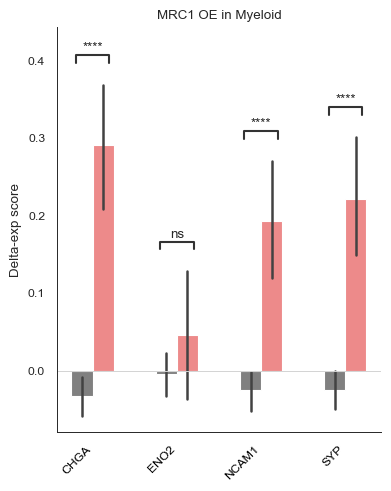

In [18]:
# Create the visualization
sns.set_theme(context='paper', style='white')

ax = tu_isp_sim.vis_delta_emb_sim_boxbar(
    stats_filt,
    model_color_map,
    title_text=f"{groups_ordered[1]} OE in Myeloid",
    xlabel_text=None,
    ylabel_text="Delta-exp score",
    figsize=(4, 5),
    wilcoxon_test="less",
    geom_type="bar",
    lg_params=lg_params,
    **plot_params
)

# Customize plot
sns.despine()
ax = plt.gca()
ax.spines['left'].set_linewidth(0.7)
ax.spines['bottom'].set_linewidth(0.7)
plt.axhline(0, color='lightgrey', linewidth=0.7, linestyle='-')

plt.legend().remove()
plt.tight_layout()
plt.show()

## Interpretation

The plot shows the distribution of delta expression scores for each marker gene:
- **Background_C1**: Random gene perturbations in Monocyte (control)
- **MRC1**: Target gene (MRC1) overexpression in Monocyte

Key points to interpret:
1. **Higher scores** indicate greater predicted expression change for the marker gene
2. **Statistical significance** (p-value from one-sided Wilcoxon test) indicates whether MRC1 perturbation has higher effect than random genes